# 1. Configure root to use src

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
print(PROJECT_ROOT)

c:\Users\Carlos\Documents\Ingenieria_informatica\Proyectos_datascience\2_titanic


# 2. Imports

In [3]:
import pandas as pd                                     # Manejar DataFrames
from pathlib import Path                                # Manejar rutas
import matplotlib.pyplot as plt                         # Gráficos
import numpy as np                                      # Operaciones matemáticas
from src.feature_engineering import extract_title, rename_titles

# 3. Import data

In [4]:
df = pd.read_csv(PROJECT_ROOT / 'data' / 'clean' / 'clean_data.csv')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


# 4. Transform binary sex

In [6]:
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    int64  
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(6), str(3)
memory usage: 76.7 KB


# 5. Drop unnecessary features

PassengerId, Name y Ticket dificilmente nos pueda dar alguna señal importante, asi que las eliminaremos

In [8]:
total_categories_passengerid = df['PassengerId'].nunique()
total_categories_name = df['Name'].nunique()
total_categories_ticket = df['Ticket'].nunique()
total_rows_xtrain = len(df)

In [9]:
print(f"""
Categorias diferentes por filas totales
PassengerId: {total_categories_passengerid}/{total_rows_xtrain}
Name: {total_categories_name}/{total_rows_xtrain}
Ticket: {total_categories_ticket}/{total_rows_xtrain}
""")


Categorias diferentes por filas totales
PassengerId: 891/891
Name: 891/891
Ticket: 681/891



Eliminar, dejamos Name ya que nos servirá para hacer feature engineering, pero luego la vamos a eliminar de todas formas

In [10]:
df.drop(columns=['PassengerId', 'Ticket'], inplace=True)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    int64  
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  889 non-null    str    
dtypes: float64(2), int64(5), str(2)
memory usage: 62.8 KB


# 6. Feature engineering

Constante para colores

In [12]:
SURVIVED_COLORS = ["#ff4343", "#3a68fd"]

Constante para orden de survived

In [13]:
SURVIVED_ORDER = [0, 1]

Constante para tener la ruta donde guardar plots

In [14]:
FEAT_ENG_FIGURES_PATH = PROJECT_ROOT / 'outputs' / 'feature_engineering_figures'

## 6.1 FamilySize

Crearemos un feature que indique la cantidad total de la familia con la que estaba la persona.

In [15]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",1,35.0,0,0,8.0500,S


In [16]:
# +1 para que se considere como que es solo 1 persona sola, sin acompañantes
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

Veamos si produce señal en Survived

In [17]:
df['FamilySize'].nunique()

9

In [18]:
group_family_size_survived_rate = df.groupby('FamilySize')['Survived'].agg(['mean', 'count'])
group_family_size_survived_rate

,mean,count
FamilySize,,
1,0.303538,537
2,0.552795,161
3,0.578431,102
4,0.724138,29
5,0.200000,15
6,0.136364,22
7,0.333333,12
8,0.000000,6
11,0.000000,7


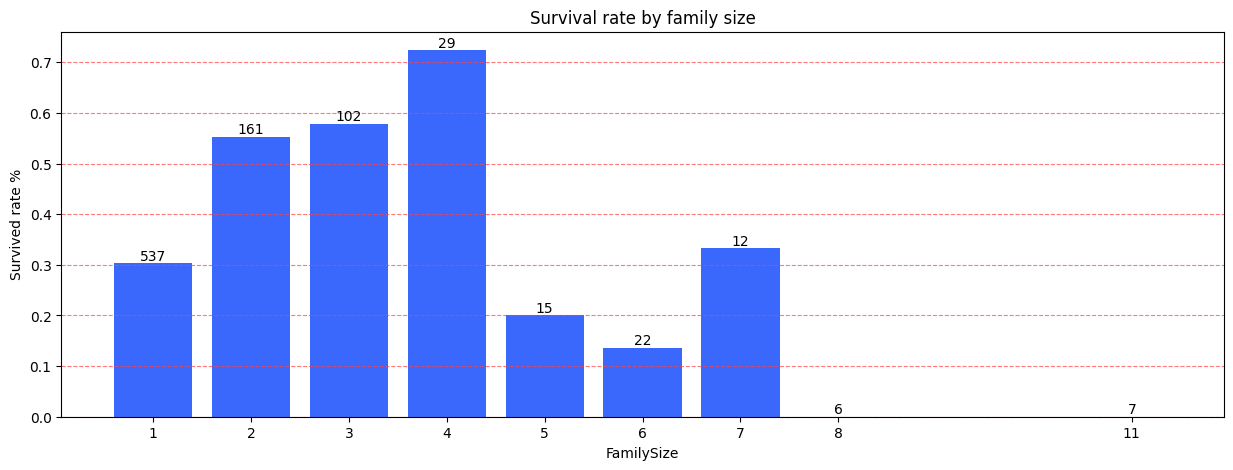

In [19]:
fig, ax = plt.subplots(figsize=(15, 5))

bars = ax.bar(
    group_family_size_survived_rate.index,
    group_family_size_survived_rate['mean'],
    color=SURVIVED_COLORS[1]
)

ax.grid(axis='y', linestyle='--', color=SURVIVED_COLORS[0], alpha=0.7)

ax.bar_label(bars, labels=group_family_size_survived_rate['count'])

ax.set_xticks(group_family_size_survived_rate.index)
ax.set_xticklabels(group_family_size_survived_rate.index)

ax.set_ylabel('Survived rate %')
ax.set_xlabel('FamilySize')

ax.set_title('Survival rate by family size')

plt.savefig(FEAT_ENG_FIGURES_PATH / '01_survival_rate_by_famili_size.png', bbox_inches='tight')
plt.show()

## 6.2 IsAlone

Gracias a family size podemos ver si la persona estaba abordo sola o con acompañantes

In [20]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

Visualizar si produce señal

Survived
0    175
1    179
Name: count, dtype: int64
Survived
0    374
1    163
Name: count, dtype: int64


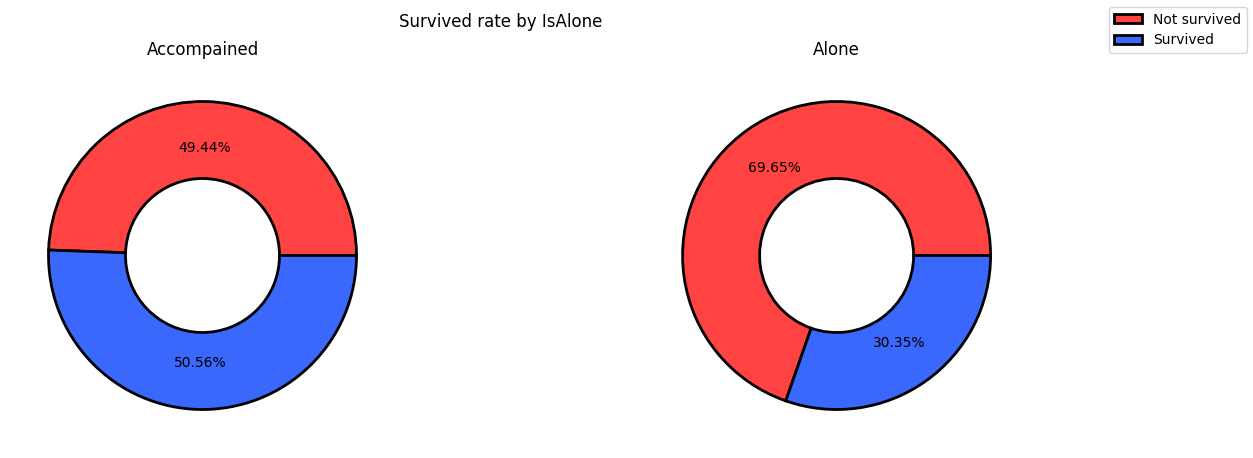

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for is_alone in np.arange(df['IsAlone'].nunique()):
    value_count_alone_type = df[df['IsAlone'] == is_alone]['Survived'].value_counts().reindex(SURVIVED_ORDER)
    print(value_count_alone_type)

    ax[is_alone].pie(
        value_count_alone_type,
        colors=SURVIVED_COLORS,
        autopct='%1.2f%%',
        pctdistance=0.7,
        wedgeprops={
            'edgecolor': 'black',
            'linewidth': 2,
            'width': 0.5
        }
    )
    ax[is_alone].set_title('Alone' if is_alone == 1 else 'Accompained')

fig.suptitle('Survived rate by IsAlone')

fig.legend(['Not survived', 'Survived'])

plt.savefig(FEAT_ENG_FIGURES_PATH / '02_survival_rate_by_isalone.png', bbox_inches='tight')
plt.show()

## 6.3 Title

Ahora crearemos un feature con el título del pasajero. Ej: Mr, Mrs, Miss

In [22]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,7.2500,S,2,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,71.2833,C,2,0
2,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,7.9250,S,1,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,53.1000,S,2,0
4,0,3,"Allen, Mr. William Henry",1,35.0,0,0,8.0500,S,1,1


In [23]:
titles = df['Name'].apply(extract_title)
titles.head()

0      Mr
1     Mrs
2    Miss
3     Mrs
4      Mr
Name: Name, dtype: str

In [24]:
df['Title'] = titles

Eliminar Name, ya pudimos extraer el title

In [25]:
df.drop(columns='Name', inplace=True)

In [26]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
0,0,3,1,22.0,1,0,7.2500,S,2,0,Mr
1,1,1,0,38.0,1,0,71.2833,C,2,0,Mrs
2,1,3,0,26.0,0,0,7.9250,S,1,1,Miss
3,1,1,0,35.0,1,0,53.1000,S,2,0,Mrs
4,0,3,1,35.0,0,0,8.0500,S,1,1,Mr


In [27]:
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

Solo Mr, Miss, Mrs y Master son títulos comunes, dejaremos el resto agrupado como Other

In [28]:
df['Title'] = df['Title'].apply(rename_titles)

In [29]:
df['Title'].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64

Visualizar señal

In [30]:
survival_rate_by_title = df.groupby('Title')['Survived'].agg(['mean', 'count'])
survival_rate_by_title

,mean,count
Title,,
Master,0.575000,40
Miss,0.697802,182
Mr,0.156673,517
Mrs,0.792000,125
Other,0.444444,27


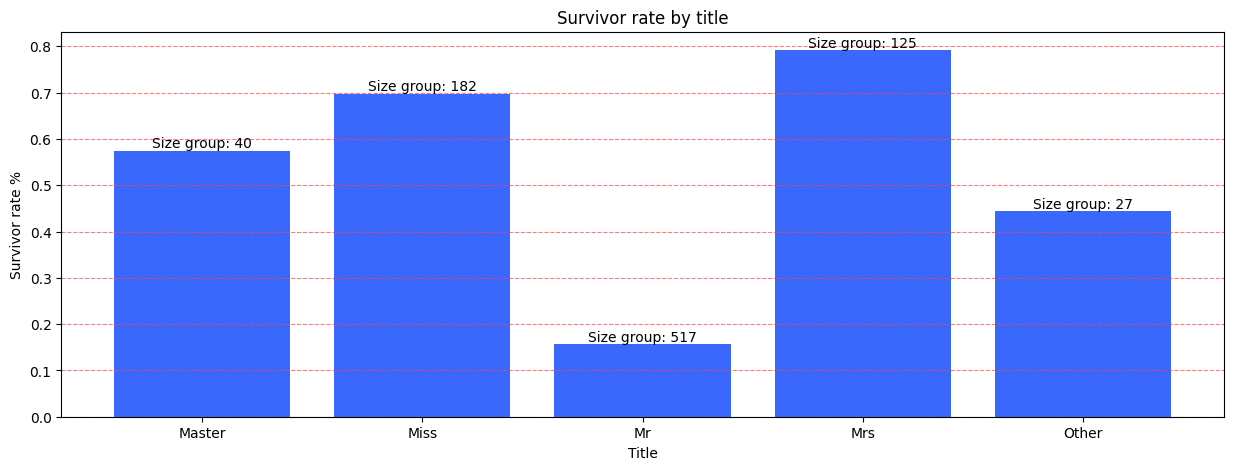

In [34]:
fig, ax = plt.subplots(figsize=(15, 5))

bars = ax.bar(
    survival_rate_by_title.index,
    height=survival_rate_by_title['mean'],
    color=SURVIVED_COLORS[1]
)

ax.bar_label(bars, labels=[f'Size group: {count}' for count in survival_rate_by_title['count']])
ax.grid(axis='y', linestyle='--', color=SURVIVED_COLORS[0], alpha=0.7)

plt.xlabel('Title')
plt.ylabel('Survivor rate %')
plt.title('Survivor rate by title')

plt.savefig(FEAT_ENG_FIGURES_PATH / '03_survivor_rate_by_title.png', bbox_inches='tight')
plt.show()

# 7. Save

Guardaremos cada DataFrame para que esté listo para ser utilizado en modeling

In [32]:
df.to_csv(PROJECT_ROOT / 'data' / 'processed' / 'processed_data.csv', index=False)